In [44]:
# 1. Clone mã nguồn từ nhánh quang
!git clone -b quang https://github.com/Anh-Quoc-Pham/inventory_optimization.git
%cd inventory_optimization

# 2. Thiết lập đường dẫn thư mục và import thư viện cơ bản
import sys
import os
from pathlib import Path
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

sys.path.append('/content/inventory_optimization/src')
warnings.filterwarnings('ignore')

# 3. Sinh dữ liệu mẫu (Cửa hàng, Sản phẩm, Doanh số, Tồn kho)
!python src/main.py --generate-data

print("\n--- Môi trường đã sẵn sàng ---")

Cloning into 'inventory_optimization'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (216/216), done.
remote: Compressing objects: 100% (163/163), done.
remote: Total 216 (delta 94), reused 160 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (216/216), 19.72 MiB | 17.66 MiB/s, done.
Resolving deltas: 100% (94/94), done.
/content/inventory_optimization/inventory_optimization/inventory_optimization/inventory_optimization/inventory_optimization/inventory_optimization/inventory_optimization/inventory_optimization/inventory_optimization

=== DATA GENERATION ===
2026-05-03 16:25:54 - optimization_data_generation - INFO - ============================================================
2026-05-03 16:25:54 - optimization_data_generation - INFO - ============================================================
2026-05-03 16:25:54 - optimization_data_generation - INFO - Starting Data Generation Execution
2026-05-03 16:25:54 - optimization_data_generation - INFO - ==

In [45]:
from src.config import (
    DATA_DIR, RESULTS_DIR,
    MIN_INVENTORY_DAYS, MAX_INVENTORY_DAYS,
    GA_POPULATION_SIZE, GA_GENERATIONS,
    REQUIRED_DATA_FILES
)

from src.engine.analyzer import InventoryAnalyzer
from src.engine.rule_based import RuleBasedOptimizer
from src.engine.genetic_algorithm import GeneticAlgorithmOptimizer
from src.engine.simplex_optimizer import SimplexOptimizer  # Thành phần mới tích hợp

print(f"Cấu hình nạp thành công: Min DoS={MIN_INVENTORY_DAYS}, Max DoS={MAX_INVENTORY_DAYS}")

Cấu hình nạp thành công: Min DoS=7, Max DoS=21


In [46]:
data_path = Path('/content/inventory_optimization/data')

# Nạp dữ liệu thô
sales_df = pd.read_csv(data_path / 'sales_data.csv', parse_dates=['date'])
inventory_df = pd.read_csv(data_path / 'inventory_data.csv')
stores_df = pd.read_csv(data_path / 'stores.csv')
products_df = pd.read_csv(data_path / 'products.csv')

# Nạp và chuẩn hóa ma trận (Rất quan trọng cho Simplex)[cite: 5]
distance_matrix = pd.read_csv(data_path / 'distance_matrix.csv', index_col=0)
transport_cost_matrix = pd.read_csv(data_path / 'transport_cost_matrix.csv', index_col=0)

# Ép kiểu index và column sang số nguyên
for matrix in [distance_matrix, transport_cost_matrix]:
    matrix.index = matrix.index.astype(int)
    matrix.columns = matrix.columns.astype(int)

inventory_df['store_id'] = inventory_df['store_id'].astype(int)

print("Tất cả dữ liệu và ma trận đã được nạp và chuẩn hóa kiểu dữ liệu.")

Tất cả dữ liệu và ma trận đã được nạp và chuẩn hóa kiểu dữ liệu.


In [47]:
analyzer = InventoryAnalyzer(
    sales_df=sales_df,
    inventory_df=inventory_df,
    stores=stores_df,
    products=products_df
)

# Chạy phân tích
analysis_df = analyzer.analyze_sales_data()
excess_df, needed_df = analyzer.identify_inventory_imbalances()

print(f"Phân tích hoàn tất:")
print(f" - Tổng mặt hàng thừa: {len(excess_df)} (Số lượng: {excess_df['excess_units'].sum():,})")
print(f" - Tổng mặt hàng thiếu: {len(needed_df)} (Số lượng: {needed_df['needed_units'].sum():,})")

Analyzing sales data...
Sales data analysis complete.
Identifying inventory imbalances...
Inventory Status Summary:
- Excess inventory items: 231 (total units: 17664)
- Needed inventory items: 128 (total units: 2527)
- Balanced inventory items: 241
Phân tích hoàn tất:
 - Tổng mặt hàng thừa: 231 (Số lượng: 17,664)
 - Tổng mặt hàng thiếu: 128 (Số lượng: 2,527)


In [48]:
results_dict = {}

# --- 1. Chạy Rule-Based (Heuristic) ---
print("Đang chạy Rule-Based...")
rule_opt = RuleBasedOptimizer(distance_matrix, transport_cost_matrix)
start = datetime.now()
rule_plan = rule_opt.optimize(excess_df, needed_df)
rule_time = (datetime.now() - start).total_seconds()
results_dict["Rule-Based"] = {"plan": rule_plan, "time": rule_time}

# --- 2. Chạy Genetic Algorithm (Metaheuristic) ---
print("Đang chạy GA (có thể mất thời gian)...")
ga_opt = GeneticAlgorithmOptimizer(distance_matrix, transport_cost_matrix)
start = datetime.now()
ga_plan = ga_opt.optimize(excess_df, needed_df, population_size=50, num_generations=20)
ga_time = (datetime.now() - start).total_seconds()
results_dict["Genetic Algorithm"] = {"plan": ga_plan, "time": ga_time}

# --- 3. Chạy Simplex Optimizer (Exact Method) ---
print("Đang chạy Simplex...")
simplex_opt = SimplexOptimizer(distance_matrix, transport_cost_matrix)
start = datetime.now()
simplex_plan = simplex_opt.optimize(excess_df, needed_df)
simplex_time = (datetime.now() - start).total_seconds()
results_dict["Simplex"] = {"plan": simplex_plan, "time": simplex_time}

print("\n--- Hoàn thành tính toán tối ưu ---")

2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - ============================================================
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - ============================================================
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Starting Rule Based Optimization Execution
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - ============================================================
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Execution Parameters:
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO -   - excess_items: 231
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO -   - needed_items: 128
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO -   - algorithm: Rule-Based Optimization
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Log file: logs/2026-05-03/rule_based_optimization.log
202

Đang chạy Rule-Based...
Generating rule-based transfer plan...


Processing needed inventory: 100%|██████████| 128/128 [00:00<00:00, 235.90item/s, product=14, store=12]
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Rule-Based Transfer Plan Summary:
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Total transfers: 150
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Total units to transfer: 2527
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Total transport cost: 289,053,290 VND
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Average cost per unit: 114,386 VND
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - ------------------------------------------------------------
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Rule Based Optimization Execution Completed
2026-05-03 16:26:18 - optimization_rule_based_optimization - INFO - Total Execution Time: 0.60 seconds
2026-05-03 16:26:18 - optimization_rule_based_optimiza

Rule-Based Transfer Plan Summary:
- Total transfers: 150
- Total units to transfer: 2527
- Total transport cost: 289,053,290 VND
- Average cost per unit: 114,386 VND
Đang chạy GA (có thể mất thời gian)...
Starting Genetic Algorithm Optimization...
Population: 50, Generations: 20
Starting Genetic Algorithm Optimization...
Population: 50, Generations: 20
Found 30 products for optimization

Step 1: Creating initial population...
Step 2: Evaluating initial fitness...


2026-05-03 16:26:21 - optimization_genetic_algorithm_optimization - INFO - Step 3: Evolution over 20 generations...



Step 3: Evolution over 20 generations...


GA Evolution: 100%|██████████| 20/20 [08:03<00:00, 24.19s/gen, Best=992,708,643, Avg=1,021,918,222, Transfers=353]
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Step 4: Extracting best solution...
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Genetic Algorithm Results:
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Best fitness (total cost): 992,708,643
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Total transfers: 353
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Total units to transfer: 1788
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Total transport cost: 992,708,643
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - Average cost per unit: 555,206
2026-05-03 16:34:24 - optimization_genetic_algorithm_optimization - INFO - ------------------------------------------------------------
2026-0


Step 4: Extracting best solution...

Genetic Algorithm Results:
   • Best fitness (total cost): 992,708,643
   • Total transfers: 353
   • Total units to transfer: 1788
   • Total transport cost: 992,708,643
   • Average cost per unit: 555,206
Đang chạy Simplex...


2026-05-03 16:34:25 - optimization_simplex_optimization - INFO - ------------------------------------------------------------
2026-05-03 16:34:25 - optimization_simplex_optimization - INFO - Simplex Optimization Execution Completed
2026-05-03 16:34:25 - optimization_simplex_optimization - INFO - Total Execution Time: 0.40 seconds
2026-05-03 16:34:25 - optimization_simplex_optimization - INFO - Execution Results:
2026-05-03 16:34:25 - optimization_simplex_optimization - INFO -   - transfers: 150
2026-05-03 16:34:25 - optimization_simplex_optimization - INFO - ============================================================



--- Hoàn thành tính toán tối ưu ---


In [49]:
comparison_rows = []

for name, res in results_dict.items():
    plan = res["plan"]
    if plan is not None and not plan.empty:
        comparison_rows.append({
            'Algorithm': name,
            'Execution Time (s)': res["time"],
            'Total Transfers': len(plan),
            'Total Units': plan['units'].sum(),
            'Total Cost (VND)': plan['transport_cost'].sum(),
            'Avg Cost/Unit': plan['transport_cost'].sum() / plan['units'].sum()
        })

comparison_df = pd.DataFrame(comparison_rows)
# Định dạng hiển thị số cho đẹp
pd.options.display.float_format = '{:,.2f}'.format
display(comparison_df)

,Algorithm,Execution Time (s),Total Transfers,Total Units,Total Cost (VND),Avg Cost/Unit
0,Rule-Based,0.61,150,2527,"289,053,289.90","114,385.95"
1,Genetic Algorithm,486.19,353,1788,"992,708,642.89","555,206.18"
2,Simplex,0.40,150,2527,"287,300,127.52","113,692.18"


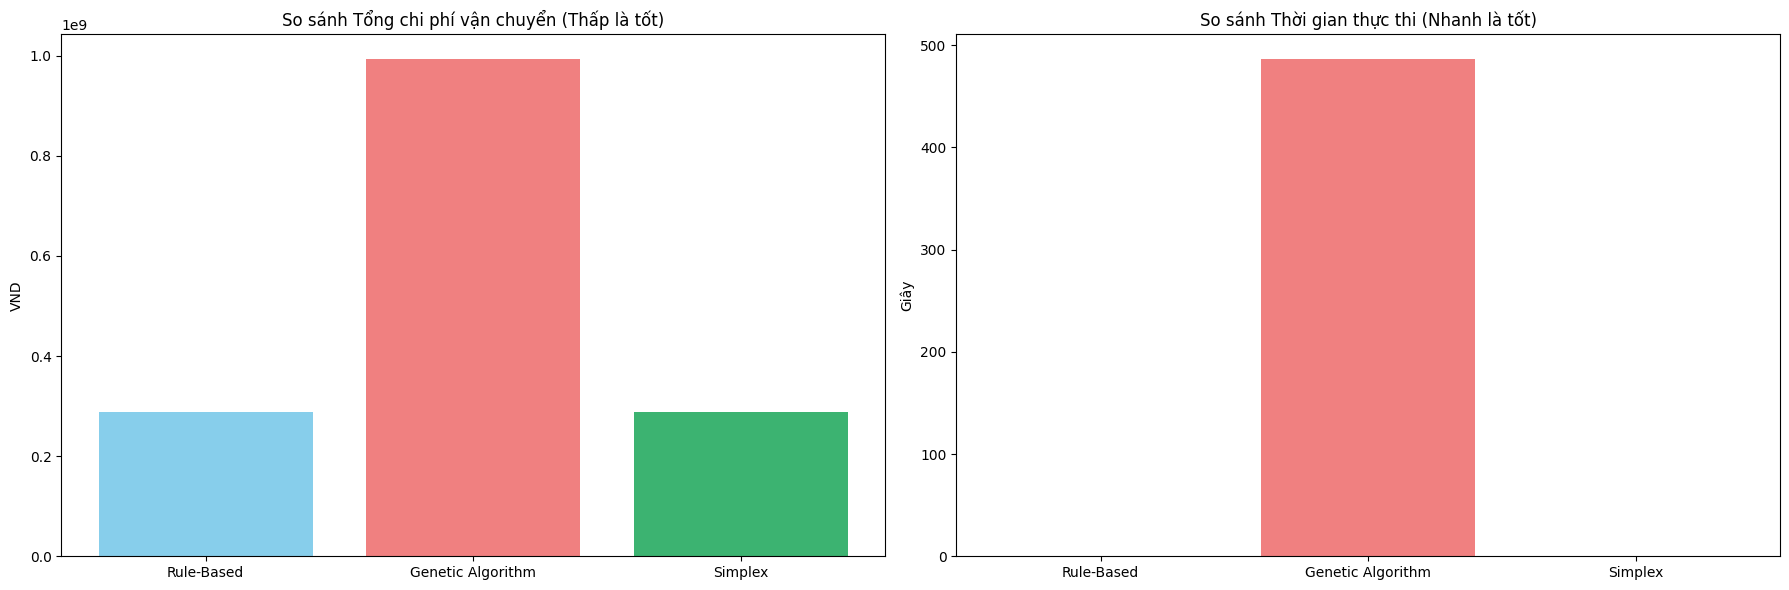

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

colors = ['skyblue', 'lightcoral', 'mediumseagreen']

# Biểu đồ Chi phí
ax1.bar(comparison_df['Algorithm'], comparison_df['Total Cost (VND)'], color=colors)
ax1.set_title('So sánh Tổng chi phí vận chuyển (Thấp là tốt)')
ax1.set_ylabel('VND')

# Biểu đồ Thời gian
ax2.bar(comparison_df['Algorithm'], comparison_df['Execution Time (s)'], color=colors)
ax2.set_title('So sánh Thời gian thực thi (Nhanh là tốt)')
ax2.set_ylabel('Giây')

plt.tight_layout()
plt.show()

In [52]:
# Tìm thuật toán có chi phí thấp nhất
best_row = comparison_df.loc[comparison_df['Total Cost (VND)'].idxmin()]

print("KẾT LUẬN CUỐI CÙNG")
print("=" * 40)
print(f"Thuật toán tối ưu nhất: {best_row['Algorithm']}")
print(f"Chi phí tiết kiệm được nhất: {best_row['Total Cost (VND)']:,.0f} VND")
print(f"Số lượng hàng điều chuyển: {best_row['Total Units']:,} sản phẩm")
print(f"Thời gian xử lý hệ thống: {best_row['Execution Time (s)']} giây")
print("-" * 40)



KẾT LUẬN CUỐI CÙNG
Thuật toán tối ưu nhất: Simplex
Chi phí tiết kiệm được nhất: 287,300,128 VND
Số lượng hàng điều chuyển: 2,527 sản phẩm
Thời gian xử lý hệ thống: 0.403362 giây
----------------------------------------


In [59]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

def visualize_detailed_map(transfer_plan, stores_df, products_df, top_n=15):
    """
    Vẽ bản đồ luân chuyển chi tiết:
    - Mũi tên chỉ hướng di chuyển.
    - Nhãn hiển thị Tên sản phẩm và Số lượng.
    - Độ dày đường nối theo số lượng.
    """
    if transfer_plan.empty:
        print("Không có dữ liệu để hiển thị.")
        return

    # 1. Lọc Top N luồng lớn nhất để bản đồ không bị rối[cite: 6]
    df = transfer_plan.nlargest(top_n, 'units').copy()

    # 2. Gộp dữ liệu để lấy tên sản phẩm và tọa độ cửa hàng
    df = df.merge(products_df[['product_id', 'product_name']], on='product_id', how='left')

    # Lấy tọa độ kho gửi (Source)
    df = df.merge(stores_df[['store_id', 'latitude', 'longitude', 'store_name']],
                 left_on='from_store_id', right_on='store_id')
    df.rename(columns={'latitude': 'lat_start', 'longitude': 'lon_start', 'store_name': 'from_name'}, inplace=True)

    # Lấy tọa độ kho nhận (Destination)
    df = df.merge(stores_df[['store_id', 'latitude', 'longitude', 'store_name']],
                  left_on='to_store_id', right_on='store_id')
    df.rename(columns={'latitude': 'lat_end', 'longitude': 'lon_end', 'store_name': 'to_name'}, inplace=True)

    fig = go.Figure()

    # 3. Vẽ từng luồng hàng hóa
    for i, row in df.iterrows():
        # Vẽ đường nối (Thân mũi tên)
        fig.add_trace(go.Scattermapbox(
            mode = "lines",
            lon = [row['lon_start'], row['lon_end']],
            lat = [row['lat_start'], row['lat_end']],
            line = dict(width = row['units']/5 + 2, color = 'royalblue'), # Độ dày theo số lượng
            opacity = 0.7,
            hoverinfo = 'text',
            text = f"Sản phẩm: {row['product_name']}<br>Số lượng: {row['units']}"
        ))

        # Tính toán điểm gần cuối đường (để vẽ đầu mũi tên chỉ hướng)
        # Điểm này nằm ở 90% quãng đường từ điểm đầu đến điểm cuối
        arrow_lat = row['lat_start'] + 0.9 * (row['lat_end'] - row['lat_start'])
        arrow_lon = row['lon_start'] + 0.9 * (row['lon_end'] - row['lon_start'])

        # Vẽ đầu mũi tên và Nhãn (Sản phẩm + Số lượng)
        fig.add_trace(go.Scattermapbox(
            mode = "markers+text",
            lon = [arrow_lon],
            lat = [arrow_lat],
            marker = dict(size = 12, symbol = "marker", color = 'red'), # Đánh dấu hướng đến
            text = [f"{row['product_name']}: {row['units']}"], # Hiển thị tên + số lượng ngay trên bản đồ
            textposition = "top center",
            textfont = dict(size = 12, color = "black"),
            hoverinfo = 'skip'
        ))

    # 4. Vẽ vị trí các cửa hàng (Các điểm nút)
    fig.add_trace(go.Scattermapbox(
        mode = "markers",
        lon = stores_df['longitude'],
        lat = stores_df['latitude'],
        marker = dict(size = 8, color = 'black'),
        hoverinfo = 'text',
        text = stores_df['store_name']
    ))

    # 5. Cấu hình giao diện bản đồ
    fig.update_layout(
        title = f'Top {top_n} luồng di chuyển hàng hóa (Tên sản phẩm & Số lượng)',
        mapbox = dict(
            style = "open-street-map",
            center = dict(lat=df['lat_start'].mean(), lon=df['lon_start'].mean()),
            zoom = 5.5
        ),
        showlegend = False,
        margin = {"r":0,"t":50,"l":0,"b":0}
    )

    fig.show()

# --- Thực thi vẽ bản đồ ---
# Đảm bảo bạn đã có simplex_plan, stores_df và products_df từ các cell trước
visualize_detailed_map(simplex_plan, stores_df, products_df, top_n=10)